# Transformer Classifier — Custom Autograd from Scratch

Every forward-pass step is a custom `torch.autograd.Function` with **hand-derived gradients**.
All backward passes follow the same chain-rule pattern:

$$\frac{\partial \mathcal{L}}{\partial W} = \frac{\partial \mathcal{L}}{\partial O} \times \frac{\partial O}{\partial W}$$

where $O$ is the output of the current function, $W$ is a parameter or input, and $\frac{\partial \mathcal{L}}{\partial O}$ (`grad_output`) is the upstream gradient arriving from the next layer.

---

### Notation

**Overline shorthand** — throughout this notebook, a bar over any tensor denotes its gradient with respect to the scalar loss $\mathcal{L}$:

$$\overline{A} \;\equiv\; \frac{\partial \mathcal{L}}{\partial A}$$

So the chain rule $\dfrac{\partial\mathcal{L}}{\partial W} = \dfrac{\partial\mathcal{L}}{\partial O}\times\dfrac{\partial O}{\partial W}$ can be written compactly as:

$$\overline{W} = \overline{O} \times \frac{\partial O}{\partial W}$$

where $\overline{O}$ is the **upstream gradient** (what PyTorch passes in as `grad_output`), and $\dfrac{\partial O}{\partial W}$ is the **local derivative** we compute analytically for each function.

> **Example:** in `LinearProjectionFunction`, the upstream gradient is $\overline{Y} = \dfrac{\partial\mathcal{L}}{\partial Y}$. The local derivative of $Y = XW$ w.r.t. $W$ is $X^\top$, so $\overline{W} = X^\top \overline{Y}$.

---

### Tensor naming

```text
Symbol        Shape      Meaning
-----------------------------------------------
X             (N, L, d)  Input sequence
Q, K, V       (N, L, d)  Query / Key / Value projections
S             (N, L, L)  Scaled dot-product scores
alpha         (N, L, L)  Softmax attention weights
H1, H2        (N, L, d)  Attention block outputs
h_pool        (N, d)     Mean-pooled representation
z             (N, 1)     Pre-sigmoid logits
p             (N,)       Predicted probabilities
```

Using a monospaced block here avoids line-wrapping issues that can happen with notebook-rendered tables.


### Custom Function Inventory

| Layer | Class |
|---|---|
| Linear projection (Q/K/V) | `LinearProjectionFunction` |
| Scaled dot-product scores | `ScaledDotProductScores` |
| Row-wise softmax | `SoftmaxFunction` |
| Attention-weighted sum | `AttentionOutputFunction` |
| Mean pooling | `MeanPoolFunction` |
| Linear head | `LinearHeadFunction` |
| Sigmoid activation | `SigmoidFunction` |
| Binary cross-entropy loss | `BCELossFunction` |

## 0 · Imports

In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.optim import SGD

## 1 · Data Generation

Each sample is a sequence $X \in \mathbb{R}^{L \times d}$.

We generate Gaussian token embeddings and then perturb **one random token** in **feature 0** by an offset
$\delta_i \in \{-3, +3\}$. The label is

$$
y_i = \mathbf{1}[\delta_i > 0].
$$

So the perturbed token is the **only token that directly carries the class signal**.

### Why this setup is useful here

This notebook ends with **mean pooling** over the contextualized token representations. That creates a natural pressure on attention to **spread the informative token across the sequence** before pooling.

If the perturbed token is at position $p$, then after attention each token output is

$$
h_i = \sum_{j=1}^{L} \alpha_{i,j} v_j,
$$

and mean pooling gives

$$
m = \frac{1}{L}\sum_{i=1}^{L} h_i
  = \sum_{j=1}^{L} \left(\frac{1}{L}\sum_{i=1}^{L} \alpha_{i,j}\right) v_j.
$$

So the contribution of token $j$ to the pooled vector depends on the **average attention mass it receives across all querying tokens**.

This makes the perturbed token a natural information source:
- many tokens can assign noticeable attention to it,
- its value can be copied into multiple token representations,
- mean pooling then preserves that signal,
- and the classifier can read the sign of the perturbation.

In short, a plausible learned strategy is:

> **“Everyone should copy a bit from the informative token before averaging.”**

This does **not** force every token to attend mostly to the perturbed token, but it does make broad propagation of that signal a very natural solution for this architecture.


In [2]:
def generate_sequence_data(num_samples=1500, seq_len=6, d_model=4, seed=42):
    rng = np.random.default_rng(seed)
    X = rng.standard_normal((num_samples, seq_len, d_model)).astype(np.float32)

    # Choose one informative token per sequence.
    anomaly_pos = rng.integers(0, seq_len, size=num_samples)

    # The label is the sign of the perturbation applied to feature 0.
    offsets = rng.choice([-3.0, 3.0], size=num_samples).astype(np.float32)

    for i in range(num_samples):
        X[i, anomaly_pos[i], 0] += offsets[i]

    y = (offsets > 0).astype(np.float32)
    return torch.from_numpy(X), torch.from_numpy(y)


## 2 · Custom Autograd Functions

### How manual autograd works in this notebook

Each operation is implemented as a subclass of `torch.autograd.Function`.

**Step 1 — wrap one operation in `torch.autograd.Function`**
- define a `forward(ctx, ...)` staticmethod
- define a matching `backward(ctx, grad_output)` staticmethod
- call the op with `MyFunction.apply(...)`, not `MyFunction(...)`

**Step 2 — use `ctx` to carry information from forward to backward**
- `ctx` is a context object created by PyTorch for this specific op call
- during `forward`, we store anything needed later by calling `ctx.save_for_backward(...)`
- we can also store small non-tensor values on `ctx`, for example `ctx.scale` or `ctx.L`

**Step 3 — backward is called automatically when `loss.backward()` runs**
- PyTorch traces the graph built by the `.apply(...)` calls in the forward pass
- when `loss.backward()` is invoked, PyTorch walks that graph in reverse order
- for each custom op, it calls `backward(ctx, grad_output)` with the upstream gradient
- `backward` must return one gradient per forward input, in the same order
- return `None` for inputs that should not receive gradients

In this notebook, the chain is:

`X -> Q/K/V projections -> attention scores -> softmax -> attention output -> mean pool -> linear head -> sigmoid -> BCE loss`

Then `train_loss.backward()` runs the reverse chain:

`BCE -> sigmoid -> linear head -> mean pool -> attention output -> softmax -> scores -> Q/K/V projections`


In [3]:
class LinearProjectionFunction(torch.autograd.Function):
    # Manual autograd pattern:
    #   1) forward(ctx, ...) computes the op
    #   2) save tensors on ctx that backward will need
    #   3) backward(ctx, grad_output) receives the upstream gradient from later ops
    #
    # Forward: Y = X @ W
    # Shapes:  X (N,L,D_in),  W (D_in,D_out)  ->  Y (N,L,D_out)

    @staticmethod
    def forward(ctx, X: torch.Tensor, W: torch.Tensor) -> torch.Tensor:
        Y = torch.einsum("nld,dk->nlk", X, W)

        # ctx belongs to this specific forward call.
        # Anything saved here becomes available later inside backward().
        ctx.save_for_backward(X, W)
        return Y

    @staticmethod
    def backward(ctx, grad_Y: torch.Tensor):
        # PyTorch calls backward() during loss.backward().
        # grad_Y is the upstream gradient dL/dY coming from the next node in the graph.
        X, W = ctx.saved_tensors

        # X_bar = Y_bar * dY/dX
        #   dY/dX[n,l,d] = W[d,k]  =>  contract over k  =>  grad_Y @ W^T
        grad_X = torch.einsum("nlk,kd->nld", grad_Y, W.t())

        # W_bar = Y_bar * dY/dW
        #   dY/dW[d,k] = X[n,l,d]  =>  sum over n,l  =>  X^T @ grad_Y
        grad_W = torch.einsum("nld,nlk->dk", X, grad_Y)

        # Must return one entry per forward input, in forward-input order: (X, W)
        return grad_X, grad_W


---

### 2.2 · `ScaledDotProductScores`  —  $S = QK^\top / \sqrt{d}$

**Forward:**  $O = S_{n,q,k} = \dfrac{1}{\sqrt{d}} \displaystyle\sum_{d'} Q_{n,q,d'}\, K_{n,k,d'}$

---

**Backward w.r.t. $Q$:**

$$\overline{Q}_{n,q,d'}
= \overline{S} \times \frac{\partial S}{\partial Q}
= \frac{1}{\sqrt{d}}\sum_k \underbrace{\overline{S}_{n,q,k}}_{\text{upstream}} \cdot \underbrace{K_{n,k,d'}}_{\partial S/\partial Q}$$

**Backward w.r.t. $K$:**

$$\overline{K}_{n,k,d'}
= \overline{S} \times \frac{\partial S}{\partial K}
= \frac{1}{\sqrt{d}}\sum_q \underbrace{\overline{S}_{n,q,k}}_{\text{upstream}} \cdot \underbrace{Q_{n,q,d'}}_{\partial S/\partial K}$$

In [4]:
class ScaledDotProductScores(torch.autograd.Function):
    # Forward: S = Q @ K^T / sqrt(d),  shape (N, L, L)

    @staticmethod
    def forward(ctx, Q: torch.Tensor, K: torch.Tensor) -> torch.Tensor:
        d = Q.shape[-1]
        scale = math.sqrt(d)
        scores = torch.einsum("nqd,nkd->nqk", Q, K) / scale

        # Save tensors + small metadata needed by backward.
        ctx.save_for_backward(Q, K)
        ctx.scale = scale
        return scores

    @staticmethod
    def backward(ctx, grad_scores: torch.Tensor):
        # Called automatically during loss.backward().
        # grad_scores is dL/dS from the downstream softmax / later layers.
        Q, K = ctx.saved_tensors
        scale = ctx.scale

        # Q_bar = S_bar * dS/dQ
        grad_Q = torch.einsum("nqk,nkd->nqd", grad_scores, K) / scale

        # K_bar = S_bar * dS/dK
        grad_K = torch.einsum("nqk,nqd->nkd", grad_scores, Q) / scale

        return grad_Q, grad_K


---

### 2.3 · `SoftmaxFunction`  —  $\alpha = \text{softmax}(S)$

**Forward** (row-wise, subtract max for numerical stability):  $O = \alpha_i = e^{S_i} / \sum_j e^{S_j}$

---

**Backward:**

$$\overline{S}_i
= \overline{\alpha} \times \frac{\partial\alpha}{\partial S}
= \sum_j \underbrace{\overline{\alpha}_j}_{\text{upstream}} \cdot \underbrace{\alpha_j(\delta_{ij} - \alpha_i)}_{\partial\alpha_j/\partial S_i \;\text{(softmax Jacobian)}}$$

Expanding the sum and factoring out $\alpha_i$:

$$\overline{S}_i
= \alpha_i\,\overline{\alpha}_i \;-\; \alpha_i\sum_j \overline{\alpha}_j\,\alpha_j
= \alpha_i\Bigl(\overline{\alpha}_i - \langle\overline{\alpha},\,\alpha\rangle\Bigr)$$

The dot product $\langle\overline{\alpha},\alpha\rangle$ is computed once per row and broadcast.

In [5]:
class SoftmaxFunction(torch.autograd.Function):
    # Forward: alpha = softmax(S)  row-wise over last axis

    @staticmethod
    def forward(ctx, logits: torch.Tensor) -> torch.Tensor:
        shifted = logits - logits.amax(dim=-1, keepdim=True)  # subtract max for stability
        exp_z = shifted.exp()
        s = exp_z / exp_z.sum(dim=-1, keepdim=True)
        ctx.save_for_backward(s)
        return s

    @staticmethod
    def backward(ctx, grad_s: torch.Tensor):
        # grad_s is alpha_bar = dL/d(alpha)  (the upstream gradient)
        (s,) = ctx.saved_tensors

        # S_bar = alpha_bar * d(alpha)/dS
        #   d(alpha_j)/dS_i = alpha_j * (delta_ij - alpha_i)  [softmax Jacobian]
        #   => S_bar_i = alpha_i * (alpha_bar_i - <alpha_bar, alpha>)
        dot = (grad_s * s).sum(dim=-1, keepdim=True)   # <alpha_bar, alpha> per row
        grad_logits = s * (grad_s - dot)

        return grad_logits

---

### 2.4 · `AttentionOutputFunction`  —  $H = \alpha V$

**Forward:**  $O = H_{n,q,d} = \displaystyle\sum_k \alpha_{n,q,k}\, V_{n,k,d}$

---

**Backward w.r.t. $\alpha$:**

$$\overline{\alpha}_{n,q,k}
= \overline{H} \times \frac{\partial H}{\partial\alpha}
= \sum_d \underbrace{\overline{H}_{n,q,d}}_{\text{upstream}} \cdot \underbrace{V_{n,k,d}}_{\partial H/\partial\alpha}$$

**Backward w.r.t. $V$:**

$$\overline{V}_{n,k,d}
= \overline{H} \times \frac{\partial H}{\partial V}
= \sum_q \underbrace{\alpha_{n,q,k}}_{\partial H/\partial V} \cdot \underbrace{\overline{H}_{n,q,d}}_{\text{upstream}}$$

In [6]:
class AttentionOutputFunction(torch.autograd.Function):
    # Forward: H = alpha @ V,  shape (N, L, d)

    @staticmethod
    def forward(ctx, weights: torch.Tensor, V: torch.Tensor) -> torch.Tensor:
        out = torch.einsum("nqk,nkd->nqd", weights, V)
        ctx.save_for_backward(weights, V)
        return out

    @staticmethod
    def backward(ctx, grad_out: torch.Tensor):
        # grad_out is H_bar = dL/dH  (the upstream gradient)
        weights, V = ctx.saved_tensors

        # alpha_bar = H_bar * dH/d(alpha)
        #   dH/d(alpha)[n,q,k] = V[n,k,d]  =>  contract over d
        grad_weights = torch.einsum("nqd,nkd->nqk", grad_out, V)

        # V_bar = H_bar * dH/dV
        #   dH/dV[n,k,d] = alpha[n,q,k]  =>  contract over q
        grad_V = torch.einsum("nqk,nqd->nkd", weights, grad_out)

        return grad_weights, grad_V

---

### 2.5 · `MeanPoolFunction`  —  $h_{\text{pool}} = \frac{1}{L}\sum_\ell H_\ell$

$h_{\text{pool}} \in \mathbb{R}^{N \times d}$ is the mean of $H_2$ over the sequence dimension. The subscript "pool" distinguishes it from the overline gradient notation — $\overline{H}$ means $\partial\mathcal{L}/\partial H$, not a mean.

**Forward:**  $O = (h_{\text{pool}})_{n,d} = \dfrac{1}{L}\displaystyle\sum_{\ell} H_{n,\ell,d}$

---

**Backward:**

$$\overline{H}_{n,\ell,d}
= \overline{h_{\text{pool}}} \times \frac{\partial h_{\text{pool}}}{\partial H}
= \underbrace{(\overline{h_{\text{pool}}})_{n,d}}_{\text{upstream}} \cdot \underbrace{\frac{1}{L}}_{\partial h_{\text{pool}}/\partial H} \qquad \forall\,\ell$$

The local derivative is $1/L$ for every position $\ell$ (mean spreads gradient equally), so the upstream gradient is broadcast to all $L$ positions and scaled.

In [7]:
class MeanPoolFunction(torch.autograd.Function):
    # Forward: h_pool[n,d] = (1/L) * sum_l H[n,l,d]
    # Note: h_pool uses subscript "pool" to avoid clash with overline notation
    #       (H_bar means dL/dH, not a mean)

    @staticmethod
    def forward(ctx, attn_output: torch.Tensor) -> torch.Tensor:
        L = attn_output.shape[1]
        pooled = attn_output.sum(dim=1) / L
        ctx.L = L
        return pooled

    @staticmethod
    def backward(ctx, grad_pooled: torch.Tensor):
        # grad_pooled is h_pool_bar = dL/d(h_pool)  (the upstream gradient)
        L = ctx.L

        # H_bar = h_pool_bar * d(h_pool)/dH
        #   d(h_pool)/dH[n,l,d] = 1/L  for every l
        #   => broadcast upstream grad scaled by 1/L to all L positions
        grad_attn_output = (grad_pooled.unsqueeze(1) / L).expand(-1, L, -1).clone()

        return grad_attn_output

---

### 2.6 · `LinearHeadFunction`  —  $z = h_{\text{pool}}\,W_O + b_O$

**Forward:**  $O = z_n = (h_{\text{pool}})_n\,W_O + b_O$

---

**Backward w.r.t. $h_{\text{pool}}$:**

$$\overline{h_{\text{pool}}}_n
= \overline{z} \times \frac{\partial z}{\partial h_{\text{pool}}}
= \underbrace{\overline{z}_n}_{\text{upstream}} \cdot \underbrace{W_O^\top}_{\partial z/\partial h_{\text{pool}}}$$

**Backward w.r.t. $W_O$:**

$$\overline{W}_O
= \overline{z} \times \frac{\partial z}{\partial W_O}
= h_{\text{pool}}^\top \cdot \underbrace{\overline{z}}_{\text{upstream}} \quad\text{(summed over batch } n\text{)}$$

**Backward w.r.t. $b_O$:**

$$\overline{b}_O
= \overline{z} \times \frac{\partial z}{\partial b_O}
= \sum_n \underbrace{\overline{z}_n}_{\text{upstream}} \cdot \underbrace{1}_{\partial z/\partial b_O} \quad\text{(bias shared across batch)}$$

In [8]:
class LinearHeadFunction(torch.autograd.Function):
    # Forward: logits = h_pool @ W_O + b_O

    @staticmethod
    def forward(
        ctx,
        pooled: torch.Tensor,
        W_O: torch.Tensor,
        b_O: torch.Tensor,
    ) -> torch.Tensor:
        logits = pooled @ W_O + b_O
        ctx.save_for_backward(pooled, W_O)
        return logits

    @staticmethod
    def backward(ctx, grad_logits: torch.Tensor):
        # grad_logits is z_bar = dL/dz  (the upstream gradient)
        pooled, W_O = ctx.saved_tensors

        # h_pool_bar = z_bar * dz/d(h_pool)
        #   dz/d(h_pool) = W_O^T
        grad_pooled = grad_logits @ W_O.t()

        # W_O_bar = z_bar * dz/dW_O
        #   dz/dW_O = h_pool^T  =>  sum over batch n
        grad_W_O = pooled.t() @ grad_logits

        # b_O_bar = z_bar * dz/db_O
        #   dz/db_O = 1  =>  sum over batch n  (bias shared across all samples)
        grad_b_O = grad_logits.sum(dim=0, keepdim=True)

        return grad_pooled, grad_W_O, grad_b_O

---

### 2.7 · `SigmoidFunction`  —  $p = \sigma(z)$

**Forward:**  $O = p = \sigma(z) = \dfrac{1}{1+e^{-z}}$

---

**Backward:**

$$\overline{z}
= \overline{p} \times \frac{\partial p}{\partial z}
= \underbrace{\overline{p}}_{\text{upstream}} \cdot \underbrace{p\,(1-p)}_{\sigma'(z)}$$

The identity $\sigma'(z) = \sigma(z)(1-\sigma(z)) = p(1-p)$ means we can reuse the stored $p$ from forward — no need to recompute $e^{-z}$.

In [9]:
class SigmoidFunction(torch.autograd.Function):
    # Forward: p = 1 / (1 + exp(-z))

    @staticmethod
    def forward(ctx, z: torch.Tensor) -> torch.Tensor:
        p = 1.0 / (1.0 + torch.exp(-z))
        ctx.save_for_backward(p)
        return p

    @staticmethod
    def backward(ctx, grad_p: torch.Tensor):
        # grad_p is p_bar = dL/dp  (the upstream gradient)
        (p,) = ctx.saved_tensors

        # z_bar = p_bar * dp/dz
        #   dp/dz = sigma'(z) = p * (1 - p)
        grad_z = grad_p * p * (1.0 - p)

        return grad_z

---

### 2.8 · `BCELossFunction`

**Forward:**  $O = \mathcal{L} = -\dfrac{1}{N}\displaystyle\sum_n\bigl[y_n\log p_n + (1-y_n)\log(1-p_n)\bigr]$

Probabilities are clamped to $[\varepsilon,\,1-\varepsilon]$ to prevent $\log 0$.

---

**Backward:**

At the root of the computation graph, $\overline{\mathcal{L}} = 1$ (PyTorch passes `grad_loss = 1` by default). Differentiating the $n$-th term w.r.t. $p_n$:

$$\frac{\partial}{\partial p_n}\bigl[-y_n\log p_n - (1-y_n)\log(1-p_n)\bigr]
= -\frac{y_n}{p_n} + \frac{1-y_n}{1-p_n}$$

So the full chain rule gives:

$$\overline{p}_n
= \overline{\mathcal{L}} \times \frac{\partial\mathcal{L}}{\partial p_n}
= \underbrace{\overline{\mathcal{L}}}_{\text{upstream}} \cdot \frac{1}{N}\left(-\frac{y_n}{p_n} + \frac{1-y_n}{1-p_n}\right)$$

No gradient is returned for $y$ — it is a constant label tensor.

In [10]:
class BCELossFunction(torch.autograd.Function):
    # Forward: loss = -(1/N) * sum_n [ y_n*log(p_n) + (1-y_n)*log(1-p_n) ]

    @staticmethod
    def forward(ctx, p: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
        eps = 1e-12
        p_c = p.clamp(eps, 1.0 - eps)   # avoid log(0)
        loss = -(y_true * p_c.log() + (1.0 - y_true) * (1.0 - p_c).log()).mean()
        ctx.save_for_backward(p_c, y_true)
        return loss

    @staticmethod
    def backward(ctx, grad_loss: torch.Tensor):
        # grad_loss is L_bar = dL/dL = 1 at the root  (upstream scalar)
        p, y = ctx.saved_tensors
        N = p.shape[0]

        # p_bar = L_bar * dLoss/dp_n
        #   dLoss/dp_n = (1/N) * (-y_n/p_n + (1-y_n)/(1-p_n))
        grad_p = grad_loss * (1.0 / N) * (-y / p + (1.0 - y) / (1.0 - p))

        return grad_p, None   # None: no gradient flows to y_true

## 3 · `TransformerClassifier`

Two stacked single-head self-attention blocks, followed by mean-pool → linear head → sigmoid.

$$X
\xrightarrow{\text{Attn}_1} H_1
\xrightarrow{\text{Attn}_2} H_2
\xrightarrow{\text{MeanPool}} h_{\text{pool}}
\xrightarrow{W_O,\,b_O} z
\xrightarrow{\sigma} p$$

In [11]:
class TransformerClassifier(nn.Module):

    def __init__(self, d_model: int = 4, seq_len: int = 3, seed: int = 42) -> None:
        super().__init__()
        torch.manual_seed(seed)

        # Attention block 1:  Q1 / K1 / V1  (d_model x d_model)
        self.W_Q1 = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.W_K1 = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.W_V1 = nn.Parameter(torch.randn(d_model, d_model) * 0.1)

        # Attention block 2:  Q2 / K2 / V2  (d_model x d_model)
        self.W_Q2 = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.W_K2 = nn.Parameter(torch.randn(d_model, d_model) * 0.1)
        self.W_V2 = nn.Parameter(torch.randn(d_model, d_model) * 0.1)

        # Output classifier  (d_model -> 1)
        self.W_O = nn.Parameter(torch.randn(d_model, 1) * 0.1)
        self.b_O = nn.Parameter(torch.zeros(1, 1))

        self.d_model = d_model
        self.seq_len = seq_len

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        """
        X : (N, L, d_model)
        p : (N,)  predicted probabilities in (0, 1)

        Important:
        every custom op is invoked through `.apply(...)`.
        Those apply-calls build the autograd graph that PyTorch will later
        traverse in reverse when `loss.backward()` is called.
        """
        # -- Attention block 1 -----------------------------------------
        Q1 = LinearProjectionFunction.apply(X, self.W_Q1)
        K1 = LinearProjectionFunction.apply(X, self.W_K1)
        V1 = LinearProjectionFunction.apply(X, self.W_V1)

        scores1       = ScaledDotProductScores.apply(Q1, K1)
        attn_weights1 = SoftmaxFunction.apply(scores1)
        H1            = AttentionOutputFunction.apply(attn_weights1, V1)

        # -- Attention block 2 -----------------------------------------
        Q2 = LinearProjectionFunction.apply(H1, self.W_Q2)
        K2 = LinearProjectionFunction.apply(H1, self.W_K2)
        V2 = LinearProjectionFunction.apply(H1, self.W_V2)

        scores2       = ScaledDotProductScores.apply(Q2, K2)
        attn_weights2 = SoftmaxFunction.apply(scores2)
        H2            = AttentionOutputFunction.apply(attn_weights2, V2)

        # -- Head -------------------------------------------------------
        h_pool = MeanPoolFunction.apply(H2)                              # (N, d)
        logits = LinearHeadFunction.apply(h_pool, self.W_O, self.b_O)   # (N, 1)
        p      = SigmoidFunction.apply(logits).squeeze(-1)              # (N,)

        return p


## 4 · Training Loop (full-batch SGD)

In [12]:
def binary_cross_entropy(y_pred: torch.Tensor, y_true: torch.Tensor) -> torch.Tensor:
    return BCELossFunction.apply(y_pred, y_true)


def train(
    model: TransformerClassifier,
    X_train: torch.Tensor,
    y_train: torch.Tensor,
    X_eval: torch.Tensor,
    y_eval: torch.Tensor,
    epochs: int = 1000,
    lr: float = 0.01,
    print_every: int = 50,
) -> tuple[list[float], list[float], list[float], list[float]]:
    optimizer = SGD(model.parameters(), lr=lr)
    train_loss_history, eval_loss_history = [], []
    train_acc_history,  eval_acc_history  = [], []

    for epoch in range(epochs):
        # -- Train ------------------------------------------------------
        model.train()
        optimizer.zero_grad()
        y_pred_train = model(X_train)
        train_loss   = binary_cross_entropy(y_pred_train, y_train)
        # This single call is where PyTorch starts the reverse pass.
        # It walks the graph built by the earlier `.apply(...)` calls and invokes
        # each custom `backward(ctx, grad_output)` in reverse topological order.
        train_loss.backward()
        optimizer.step()

        train_loss_history.append(train_loss.item())
        with torch.no_grad():
            train_acc = ((y_pred_train > 0.5).float() == y_train).float().mean().item()
            train_acc_history.append(train_acc)

        # -- Eval -------------------------------------------------------
        model.eval()
        with torch.no_grad():
            y_pred_eval = model(X_eval)
            eval_loss   = binary_cross_entropy(y_pred_eval, y_eval)
            eval_loss_history.append(eval_loss.item())
            eval_acc = ((y_pred_eval > 0.5).float() == y_eval).float().mean().item()
            eval_acc_history.append(eval_acc)

        if epoch % print_every == 0 or epoch == epochs - 1:
            print(
                f"Epoch {epoch:>4}/{epochs}  "
                f"train_loss={train_loss_history[-1]:.6f}  "
                f"eval_loss={eval_loss_history[-1]:.6f}  "
                f"train_acc={train_acc:.2%}  "
                f"eval_acc={eval_acc:.2%}"
            )

    return train_loss_history, eval_loss_history, train_acc_history, eval_acc_history

## 5 · Demo: Train & Evaluate

600 samples (500 train / 100 eval), 1000 epochs, SGD $\eta = 0.01$.

In [13]:
X, y = generate_sequence_data(num_samples=600, seq_len=3, d_model=4, seed=42)
X_train, y_train = X[:500], y[:500]
X_eval,  y_eval  = X[500:], y[500:]

model = TransformerClassifier(d_model=4, seq_len=3, seed=123)

train_history, eval_history, train_acc_history, eval_acc_history = train(
    model, X_train, y_train, X_eval, y_eval,
    epochs=1000, lr=0.01, print_every=50,
)

Epoch    0/1000  train_loss=0.694278  eval_loss=0.694210  train_acc=4.40%  eval_acc=6.00%
Epoch   50/1000  train_loss=0.693841  eval_loss=0.693907  train_acc=50.60%  eval_acc=48.00%
Epoch  100/1000  train_loss=0.693435  eval_loss=0.693622  train_acc=50.80%  eval_acc=48.00%
Epoch  150/1000  train_loss=0.693047  eval_loss=0.693342  train_acc=50.80%  eval_acc=48.00%
Epoch  200/1000  train_loss=0.692662  eval_loss=0.693055  train_acc=50.80%  eval_acc=48.00%
Epoch  250/1000  train_loss=0.692267  eval_loss=0.692751  train_acc=50.80%  eval_acc=48.00%
Epoch  300/1000  train_loss=0.691848  eval_loss=0.692416  train_acc=50.80%  eval_acc=48.00%
Epoch  350/1000  train_loss=0.691388  eval_loss=0.692037  train_acc=50.80%  eval_acc=48.00%
Epoch  400/1000  train_loss=0.690868  eval_loss=0.691597  train_acc=50.80%  eval_acc=48.00%
Epoch  450/1000  train_loss=0.690268  eval_loss=0.691077  train_acc=50.80%  eval_acc=48.00%
Epoch  500/1000  train_loss=0.689557  eval_loss=0.690450  train_acc=50.80%  eval_a

In [14]:
print(f"Initial train loss : {train_history[0]:.6f}")
print(f"Final   train loss : {train_history[-1]:.6f}")
print(f"Initial eval  loss : {eval_history[0]:.6f}")
print(f"Final   eval  loss : {eval_history[-1]:.6f}")

with torch.no_grad():
    train_acc = ((model(X_train) > 0.5).float() == y_train).float().mean().item()
    eval_acc  = ((model(X_eval)  > 0.5).float() == y_eval ).float().mean().item()
print(f"\nFinal train accuracy : {train_acc:.2%}")
print(f"Final eval  accuracy : {eval_acc:.2%}")

assert train_history[-1] < train_history[0], "Train loss did not decrease!"
print("\nTrain loss decreased.")

Initial train loss : 0.694278
Final   train loss : 0.652964
Initial eval  loss : 0.694210
Final   eval  loss : 0.656429

Final train accuracy : 92.80%
Final eval  accuracy : 91.00%

Train loss decreased.


## 6 · Plots

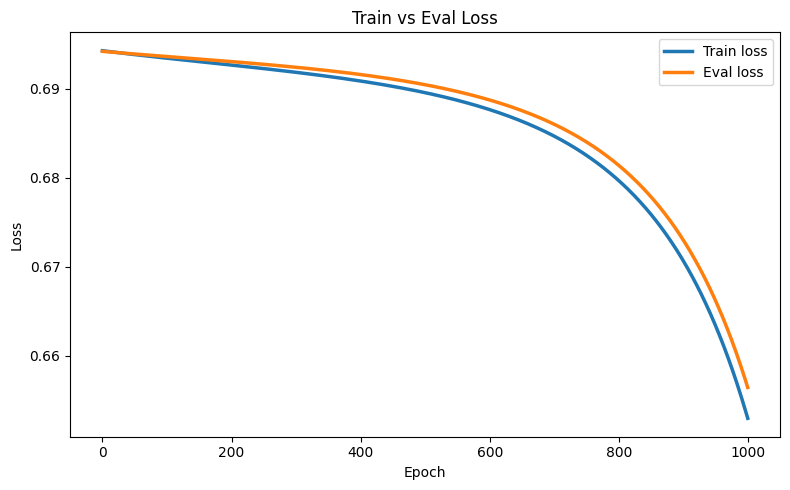

In [15]:
plt.figure(figsize=(8, 5))
plt.plot(train_history,     label="Train loss", linewidth=2.5)
plt.plot(eval_history,      label="Eval loss",  linewidth=2.5)
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Train vs Eval Loss"); plt.legend(); plt.tight_layout(); plt.show()

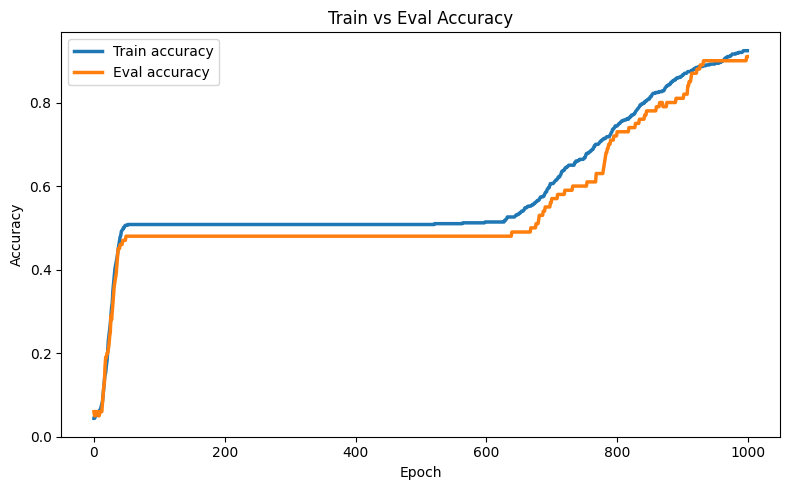

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(train_acc_history, label="Train accuracy", linewidth=2.5)
plt.plot(eval_acc_history,  label="Eval accuracy",  linewidth=2.5)
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Train vs Eval Accuracy"); plt.legend(); plt.tight_layout(); plt.show()